In [2]:
import pandas as pd
df=pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [5]:
df.describe()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
df_spending = df.drop(columns=["Channel", "Region"])


In [7]:
features = df_spending.columns.tolist()
features


['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_spending)
# Verify scaling
X_scaled.mean(axis=0), X_scaled.std(axis=0)



(array([-3.43159844e-17,  0.00000000e+00, -4.03717464e-17,  3.63345717e-17,
         2.42230478e-17, -8.07434927e-18]),
 array([1., 1., 1., 1., 1., 1.]))

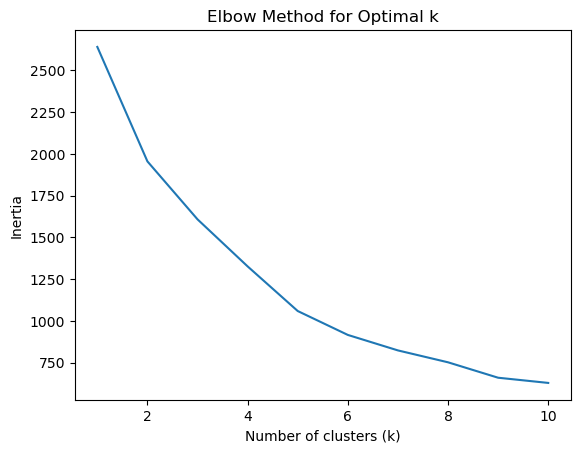

In [11]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
import matplotlib.pyplot as plt
plt.plot(K_range, inertia)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [12]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
clusters = kmeans_final.fit_predict(X_scaled)

# Add cluster labels
df["Cluster"] = clusters
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,0


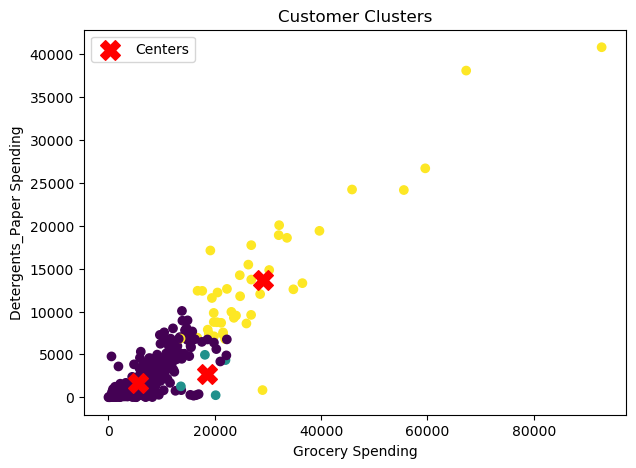

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Grocery"],
    df["Detergents_Paper"],
    c=df["Cluster"],
    cmap="viridis"
)

# Plot cluster centers (inverse scaled)
centers = scaler.inverse_transform(kmeans_final.cluster_centers_)

plt.scatter(
    centers[:, features.index("Grocery")],
    centers[:, features.index("Detergents_Paper")],
    s=200,
    c="red",
    marker="X",
    label="Centers"
)

plt.xlabel("Grocery Spending")
plt.ylabel("Detergents_Paper Spending")
plt.title("Customer Clusters")
plt.legend()
plt.show()


In [17]:
cluster_profile = df.groupby("Cluster")[df_spending.columns].mean()
cluster_profile.round(2)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,12062.91,4115.10,5534.97,2940.68,1696.17,1299.11
1,52022.00,31696.00,18490.75,29825.50,2699.00,19656.25
2,7705.07,18752.07,29054.81,1782.84,13731.77,1901.53


In [18]:
for cluster in cluster_profile.index:
    print(f"\nCluster {cluster}")
    print(cluster_profile.loc[cluster])



Cluster 0
Fresh               12062.913486
Milk                 4115.099237
Grocery              5534.966921
Frozen               2940.676845
Detergents_Paper     1696.170483
Delicassen           1299.114504
Name: 0, dtype: float64

Cluster 1
Fresh               52022.00
Milk                31696.00
Grocery             18490.75
Frozen              29825.50
Detergents_Paper     2699.00
Delicassen          19656.25
Name: 1, dtype: float64

Cluster 2
Fresh                7705.069767
Milk                18752.069767
Grocery             29054.813953
Frozen               1782.837209
Detergents_Paper    13731.767442
Delicassen           1901.534884
Name: 2, dtype: float64


In [19]:
kmeans_alt = KMeans(n_clusters=3, random_state=99)
clusters_alt = kmeans_alt.fit_predict(X_scaled)

# Compare assignments
(df["Cluster"] == clusters_alt).value_counts()


True     331
False    109
Name: Cluster, dtype: int64